In [1]:
import pandas as pd

# Dosyayı yükle
df = pd.read_csv("training.1600000.processed.noemoticon.csv", encoding='latin-1', header=None)

# Sütun isimlerini düzelt
df.columns = ['duygu', 'id', 'tarih', 'sorgu', 'kullanici', 'metin']
df = df[['duygu', 'metin']]
df['duygu'] = df['duygu'].replace({0: 'negatif', 4: 'pozitif'})


In [2]:
import re

def temizle(metin):
    metin = metin.lower()
    metin = re.sub(r"http\S+|www\.\S+", "", metin)
    metin = re.sub(r"@\w+", "", metin)
    metin = re.sub(r"[^a-zA-Z\s]", "", metin)
    metin = re.sub(r"\s+", " ", metin).strip()
    return metin

df['temiz_metin'] = df['metin'].apply(temizle)


In [3]:
print("Veri boyutu:", df.shape)

print("\nSınıf dağılımı:")
print(df["duygu"].value_counts())


Veri boyutu: (1600000, 3)

Sınıf dağılımı:
duygu
negatif    800000
pozitif    800000
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tweet uzunluğunu hesapla
df['tweet_uzunlugu'] = df['temiz_metin'].apply(len)

# Histogram
plt.figure(figsize=(12,5))
sns.histplot(df['tweet_uzunlugu'], bins=50, kde=True)
plt.title("Tweet Uzunluğu Dağılımı")
plt.xlabel("Karakter Sayısı")
plt.ylabel("Tweet Sayısı")
plt.show()

# Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=df['tweet_uzunlugu'])
plt.title


ModuleNotFoundError: No module named 'matplotlib'

In [5]:
!pip install matplotlib seaborn


     ---------------------------------------- 8.1/8.1 MB 5.0 MB/s eta 0:00:00
     -------------------------------------- 294.9/294.9 kB 6.1 MB/s eta 0:00:00
     -------------------------------------- 222.0/222.0 kB 6.8 MB/s eta 0:00:00
     ---------------------------------------- 2.2/2.2 MB 5.9 MB/s eta 0:00:00
     ---------------------------------------- 72.0/72.0 kB 4.1 MB/s eta 0:00:00
     ---------------------------------------- 2.7/2.7 MB 4.2 MB/s eta 0:00:00
     -------------------------------------- 111.1/111.1 kB 1.6 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


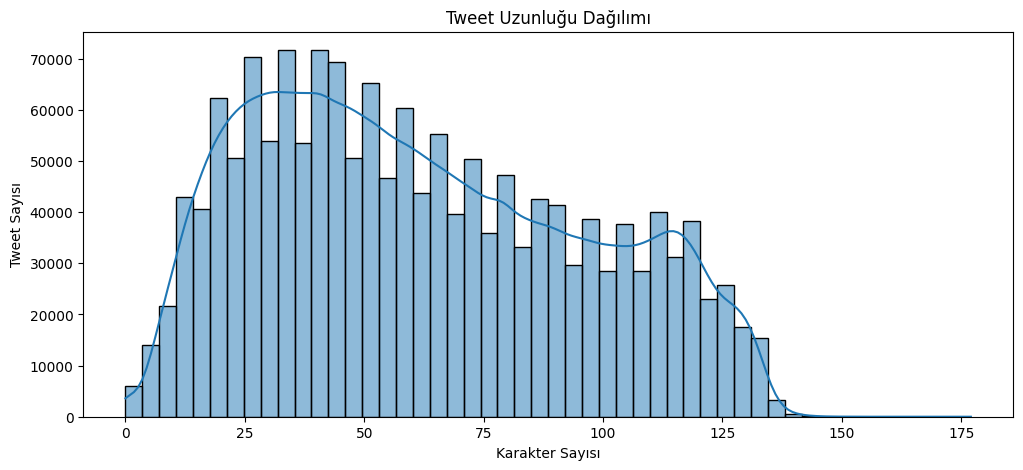

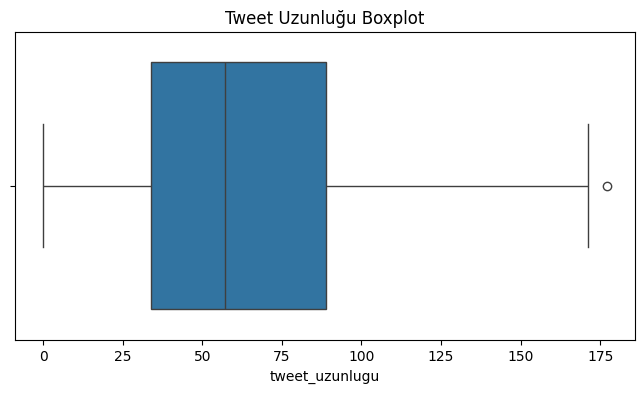

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tweet uzunluğunu hesapla
df['tweet_uzunlugu'] = df['temiz_metin'].apply(len)

# Histogram
plt.figure(figsize=(12,5))
sns.histplot(df['tweet_uzunlugu'], bins=50, kde=True)
plt.title("Tweet Uzunluğu Dağılımı")
plt.xlabel("Karakter Sayısı")
plt.ylabel("Tweet Sayısı")
plt.show()

# Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=df['tweet_uzunlugu'])
plt.title("Tweet Uzunluğu Boxplot")
plt.show()


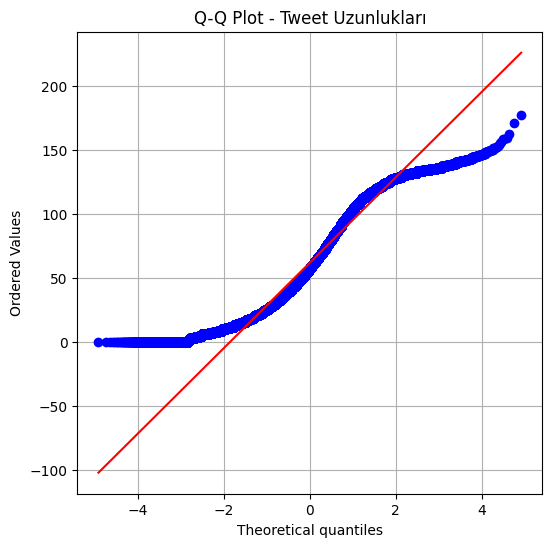

In [8]:
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(df['tweet_uzunlugu'], dist="norm", plot=plt)
plt.title("Q-Q Plot - Tweet Uzunlukları")
plt.grid()
plt.show()


In [9]:
Q1 = df['tweet_uzunlugu'].quantile(0.25)
Q3 = df['tweet_uzunlugu'].quantile(0.75)
IQR = Q3 - Q1

aykirilar = df[(df['tweet_uzunlugu'] < (Q1 - 1.5 * IQR)) | (df['tweet_uzunlugu'] > (Q3 + 1.5 * IQR))]

print("1. Çeyrek (Q1):", Q1)
print("3. Çeyrek (Q3):", Q3)
print("IQR:", IQR)
print("Aykırı değer sayısı:", aykirilar.shape[0])


1. Çeyrek (Q1): 34.0
3. Çeyrek (Q3): 89.0
IQR: 55.0
Aykırı değer sayısı: 1


In [1]:
df.isnull().sum()


NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("training.1600000.processed.noemoticon.csv", encoding='latin-1', header=None)
df.columns = ['duygu', 'id', 'tarih', 'sorgu', 'kullanici', 'metin']
df = df[['duygu', 'metin']]


In [3]:
df.isnull().sum()


duygu    0
metin    0
dtype: int64

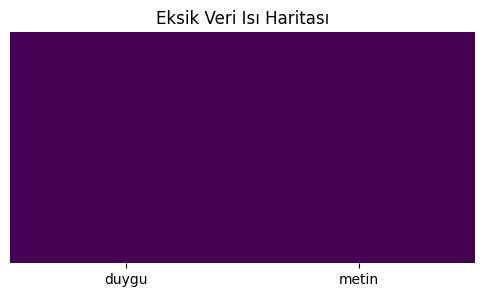

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Eksik Veri Isı Haritası")
plt.show()


In [5]:
!pip install missingno



[notice] A new release of pip available: 22.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


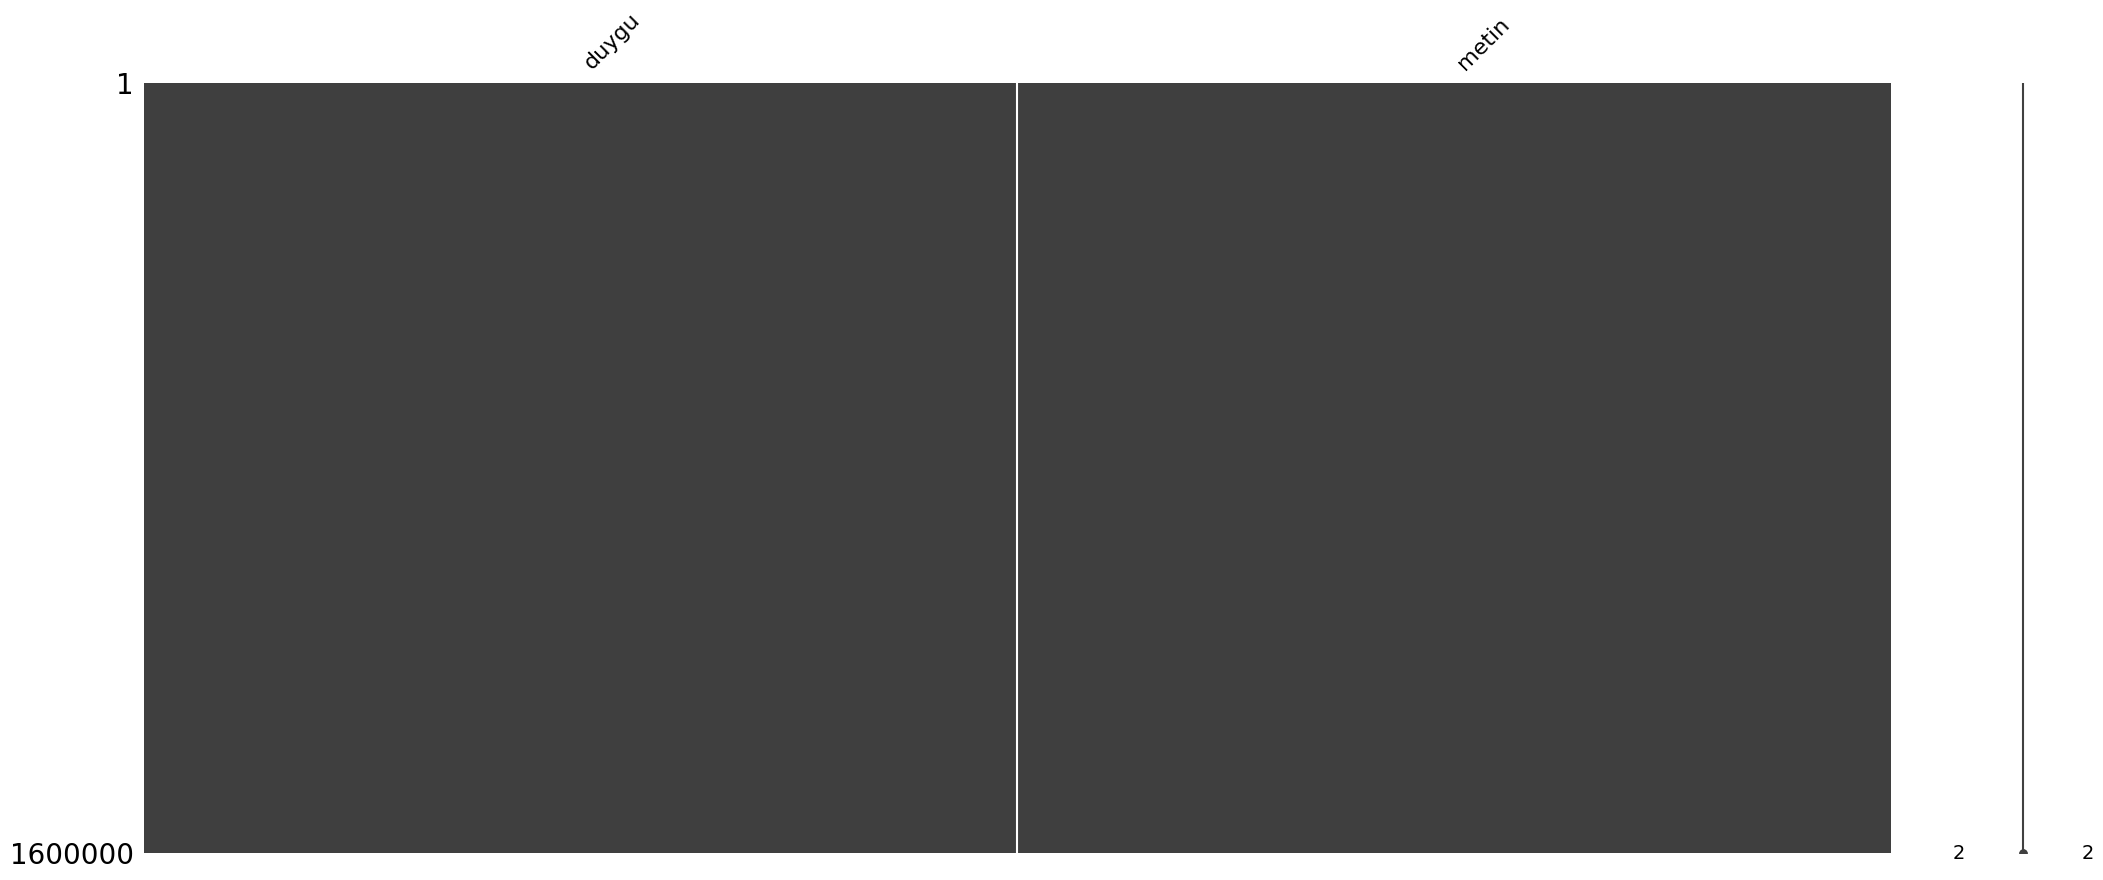

In [6]:
import missingno as msno

msno.matrix(df)
plt.show()


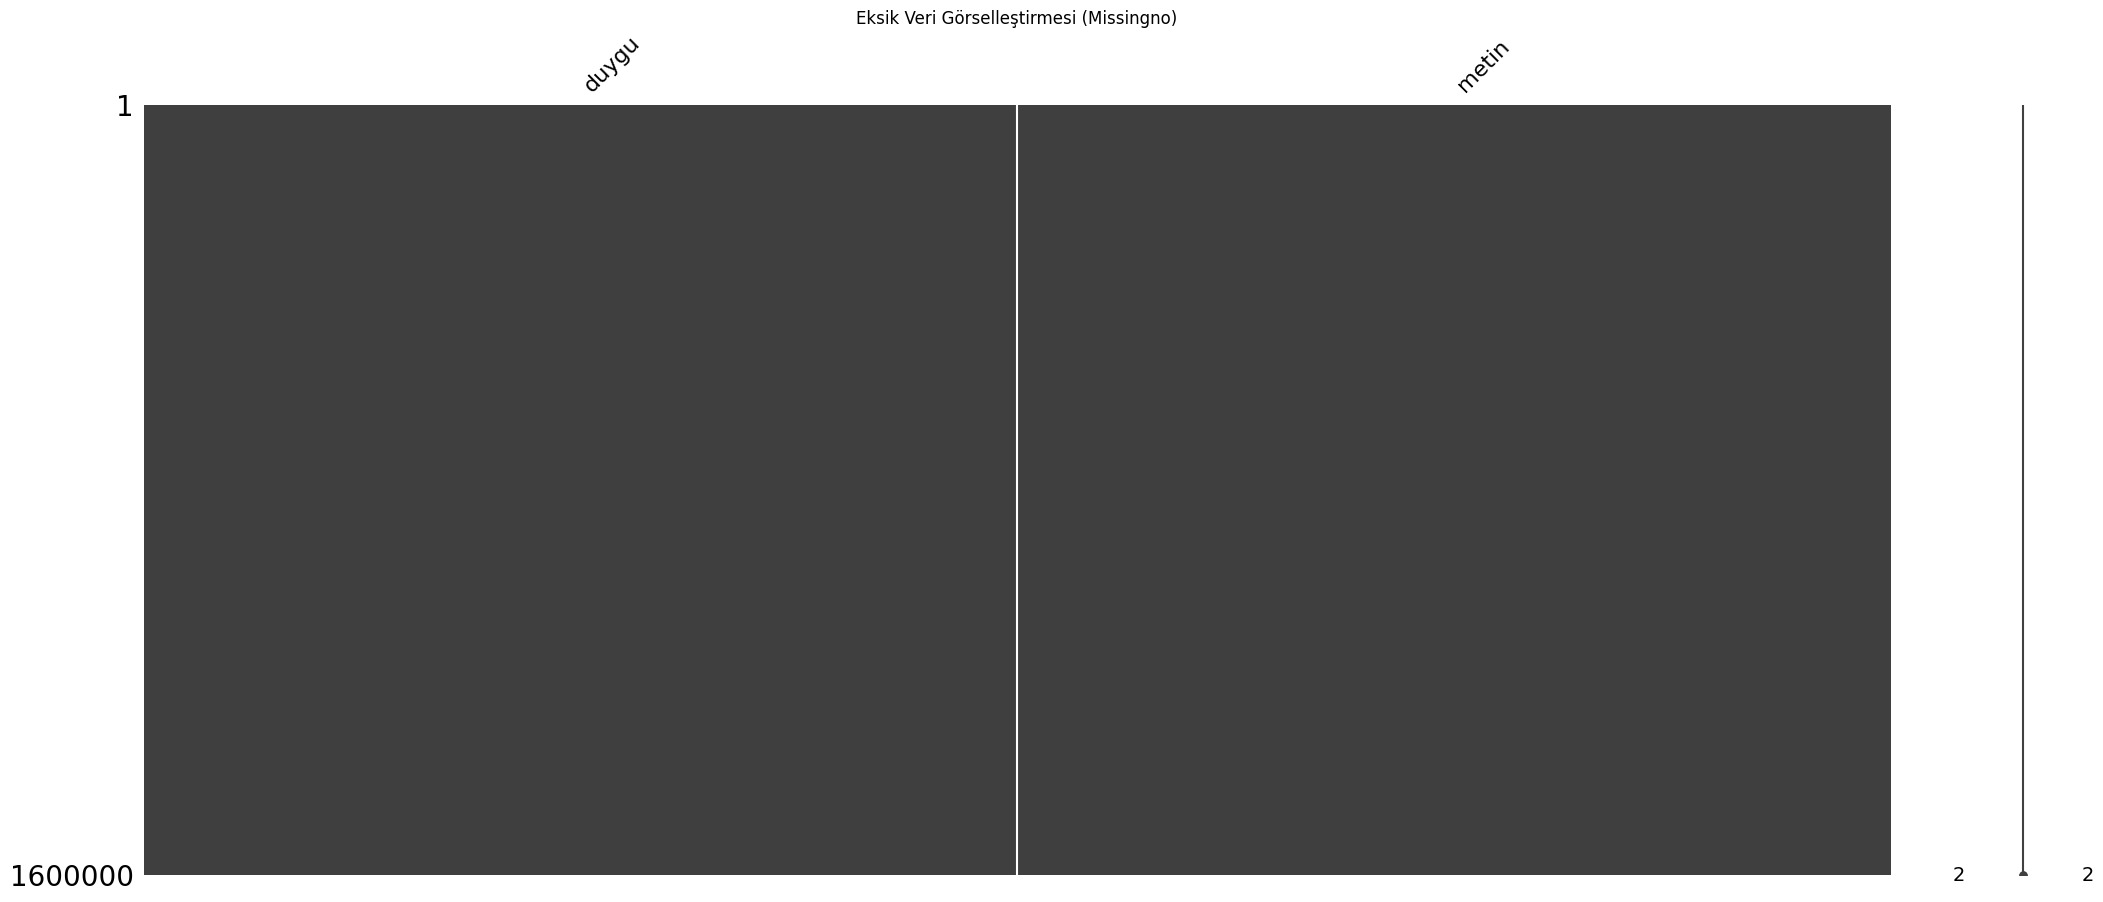

In [7]:
import missingno as msno
import matplotlib.pyplot as plt

# Eksik veri matrisini çiz
msno.matrix(df)
plt.title("Eksik Veri Görselleştirmesi (Missingno)")
plt.show()


In [8]:
df['tweet_uzunlugu'] = df['metin'].apply(len)


In [9]:
Q1 = df['tweet_uzunlugu'].quantile(0.25)
Q3 = df['tweet_uzunlugu'].quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print(f"IQR: {IQR}")
print(f"Alt sınır: {alt_sinir}")
print(f"Üst sınır: {ust_sinir}")


IQR: 60.0
Alt sınır: -46.0
Üst sınır: 194.0


In [10]:
aykiri_veri = df[(df['tweet_uzunlugu'] < alt_sinir) | (df['tweet_uzunlugu'] > ust_sinir)]
print(f"Aykırı değer sayısı: {aykiri_veri.shape[0]}")


Aykırı değer sayısı: 147


In [11]:
df = df[(df['tweet_uzunlugu'] >= alt_sinir) & (df['tweet_uzunlugu'] <= ust_sinir)]
print(f"Kalan veri sayısı: {df.shape[0]}")


Kalan veri sayısı: 1599853


In [12]:
import pandas as pd

# Değerleri bir sözlükte topla
iqr_sonuclari = {
    "Özellik": ["tweet_uzunlugu"],
    "Q1": [Q1],
    "Q3": [Q3],
    "IQR": [IQR],
    "Alt Sınır": [alt_sinir],
    "Üst Sınır": [ust_sinir],
    "Aykırı Değer Sayısı": [aykiri_veri.shape[0]],
    "Kalan Veri Sayısı": [df.shape[0]]
}

# DataFrame'e çevir
iqr_df = pd.DataFrame(iqr_sonuclari)
iqr_df


,Özellik,Q1,Q3,IQR,Alt Sınır,Üst Sınır,Aykırı Değer Sayısı,Kalan Veri Sayısı
0,tweet_uzunlugu,44.0,104.0,60.0,-46.0,194.0,147,1599853


In [13]:
from sklearn.preprocessing import PowerTransformer


In [14]:
# PowerTransformer nesnesini oluştur (Yeo-Johnson varsayılan)
pt = PowerTransformer(method='yeo-johnson')

# Dönüştürme işlemini uygula
tweet_lengths = df[['tweet_uzunlugu']]  # sadece DataFrame olarak ver
df['tweet_uzunlugu_transformed'] = pt.fit_transform(tweet_lengths)


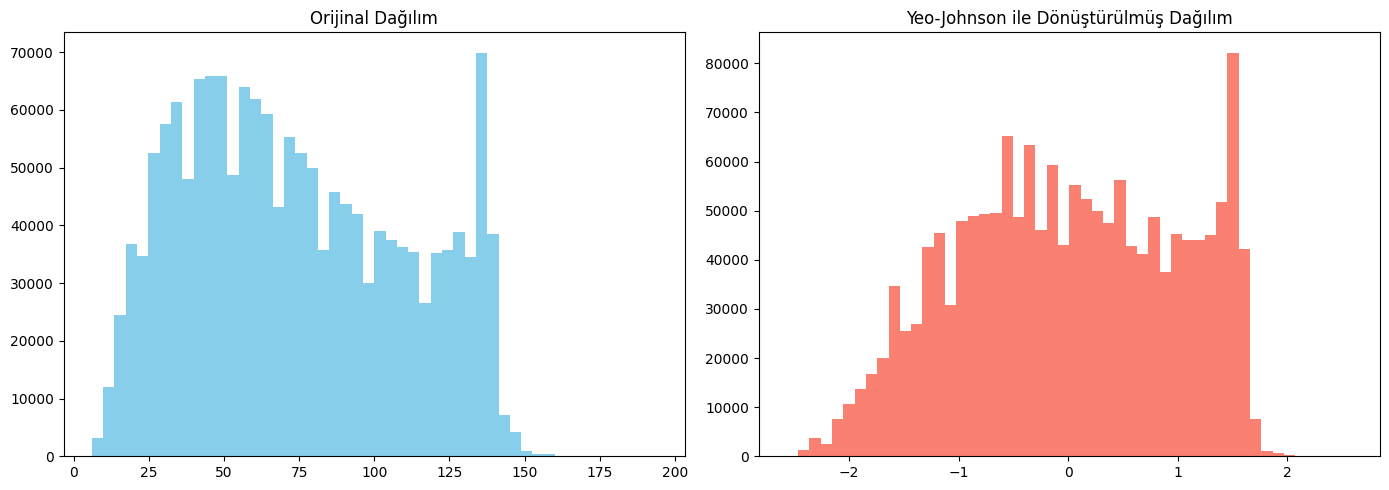

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# Orijinal dağılım
plt.subplot(1,2,1)
plt.hist(df['tweet_uzunlugu'], bins=50, color='skyblue')
plt.title("Orijinal Dağılım")

# Dönüştürülmüş dağılım
plt.subplot(1,2,2)
plt.hist(df['tweet_uzunlugu_transformed'], bins=50, color='salmon')
plt.title("Yeo-Johnson ile Dönüştürülmüş Dağılım")

plt.tight_layout()
plt.show()


In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['tweet_uzunlugu_normalized'] = scaler.fit_transform(df[['tweet_uzunlugu_transformed']])


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['tweet_uzunlugu_standardized'] = scaler.fit_transform(df[['tweet_uzunlugu_transformed']])


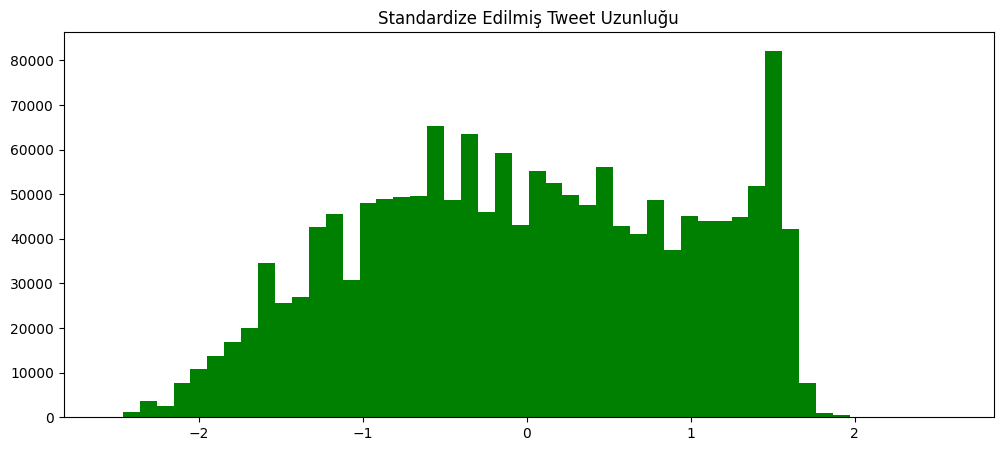

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.hist(df['tweet_uzunlugu_standardized'], bins=50, color='green')
plt.title("Standardize Edilmiş Tweet Uzunluğu")
plt.show()


In [19]:
from sklearn.preprocessing import StandardScaler

# StandardScaler nesnesini oluştur
scaler = StandardScaler()

# Yeo-Johnson ile dönüştürülmüş uzunlukları normalize et
df['tweet_uzunlugu_standardized'] = scaler.fit_transform(df[['tweet_uzunlugu_transformed']])


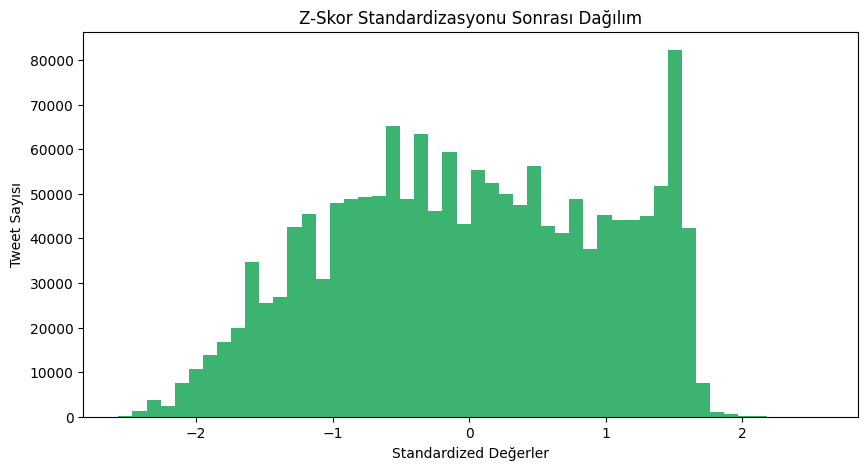

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['tweet_uzunlugu_standardized'], bins=50, color='mediumseagreen')
plt.title("Z-Skor Standardizasyonu Sonrası Dağılım")
plt.xlabel("Standardized Değerler")
plt.ylabel("Tweet Sayısı")
plt.show()


In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# TF-IDF matrisini PCA ile 2D'ye indir
pca = PCA(n_components=2)
X_pca_original = pca.fit_transform(X.toarray())

# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(X_pca_original[:, 0], X_pca_original[:, 1], c=(y=="pozitif"), cmap='coolwarm', alpha=0.4, s=1)
plt.title("Boyut İndirgeme Öncesi - PCA ile 2D Görselleştirme")
plt.xlabel("Bileşen 1")
plt.ylabel("Bileşen 2")
plt.grid(True)
plt.show()


NameError: name 'X' is not defined

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Temiz metin üzerinden TF-IDF vektörleri çıkar
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df["temiz_metin"])
y = df["duygu"]


KeyError: 'temiz_metin'

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Temiz metin üzerinden TF-IDF vektörleri çıkar
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df["temiz_metin"])
y = df["duygu"]


KeyError: 'temiz_metin'

In [27]:
import re

def temizle(metin):
    metin = metin.lower()
    metin = re.sub(r"http\S+|www\.\S+", "", metin)        # linkleri sil
    metin = re.sub(r"@\w+", "", metin)                    # mentionları sil
    metin = re.sub(r"[^a-zA-Z\s]", "", metin)             # noktalama/rakam sil
    metin = re.sub(r"\s+", " ", metin).strip()            # boşlukları düzenle
    return metin




In [28]:
df['temiz_metin'] = df['metin'].apply(temiz)


NameError: name 'temiz' is not defined

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df["temiz_metin"])
y = df["duygu"]


KeyError: 'temiz_metin'

In [30]:
import re

def temizle(metin):
    metin = metin.lower()
    metin = re.sub(r"http\S+|www\.\S+", "", metin)
    metin = re.sub(r"@\w+", "", metin)
    metin = re.sub(r"[^a-zA-Z\s]", "", metin)
    metin = re.sub(r"\s+", " ", metin).strip()
    return metin


In [31]:
df = pd.read_csv("training.1600000.processed.noemoticon.csv", encoding='latin-1', header=None)
df.columns = ['duygu', 'id', 'tarih', 'sorgu', 'kullanici', 'metin']
df = df[['duygu', 'metin']]


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df["temiz_metin"])
y = df["duygu"]


KeyError: 'temiz_metin'

In [33]:
df['temiz_metin'] = df['metin'].apply(temizle)


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df["temiz_metin"])
y = df["duygu"]


In [35]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# TF-IDF matrisini PCA ile 2D'ye indir
pca = PCA(n_components=2)
X_pca_original = pca.fit_transform(X.toarray())  # .toarray() şart çünkü sparse matris

# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(X_pca_original[:, 0], X_pca_original[:, 1], c=(y=="pozitif"), cmap='coolwarm', alpha=0.4, s=1)
plt.title("Boyut İndirgeme Öncesi - PCA ile 2D Görselleştirme")
plt.xlabel("Bileşen 1")
plt.ylabel("Bileşen 2")
plt.grid(True)
plt.show()


MemoryError: Unable to allocate 59.6 GiB for an array with shape (1600000, 5000) and data type float64

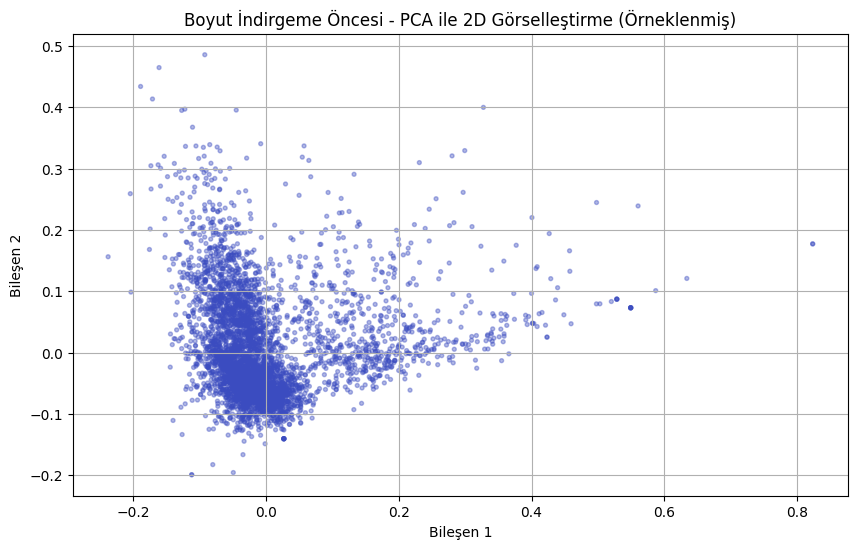

In [36]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Küçük bir örnek al
sample_size = 5000
indices = np.random.choice(X.shape[0], sample_size, replace=False)

X_sample = X[indices].toarray()
y_sample = y.iloc[indices]

# PCA uygula
pca = PCA(n_components=2)
X_pca_sample = pca.fit_transform(X_sample)

# Grafik çiz
plt.figure(figsize=(10,6))
plt.scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=(y_sample=="pozitif"), cmap='coolwarm', alpha=0.4, s=8)
plt.title("Boyut İndirgeme Öncesi - PCA ile 2D Görselleştirme (Örneklenmiş)")
plt.xlabel("Bileşen 1")
plt.ylabel("Bileşen 2")
plt.grid(True)
plt.show()


In [37]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=1000)
X_selected = selector.fit_transform(X, y)


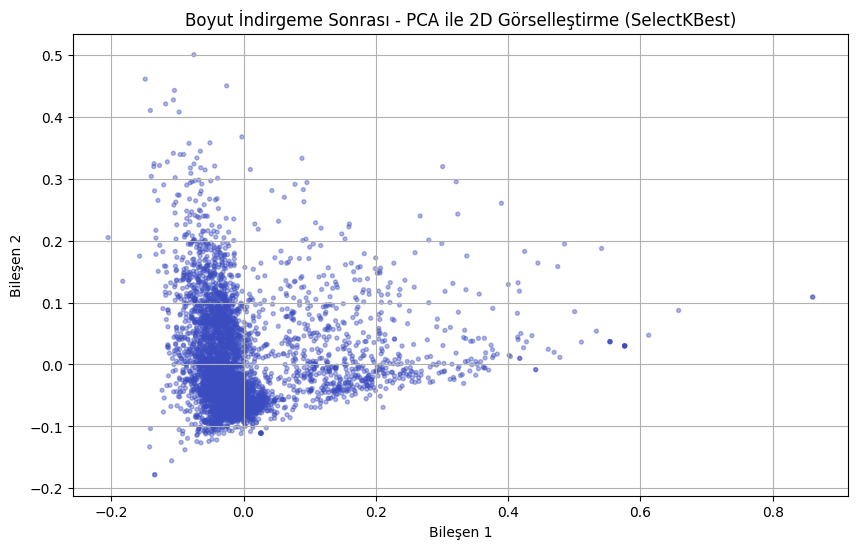

In [38]:
# Aynı indeksleri kullanalım
X_selected_sample = X_selected[indices].toarray()

# PCA uygula
X_pca_selected = PCA(n_components=2).fit_transform(X_selected_sample)

# Grafik çiz
plt.figure(figsize=(10,6))
plt.scatter(X_pca_selected[:, 0], X_pca_selected[:, 1], c=(y_sample=="pozitif"), cmap='coolwarm', alpha=0.4, s=8)
plt.title("Boyut İndirgeme Sonrası - PCA ile 2D Görselleştirme (SelectKBest)")
plt.xlabel("Bileşen 1")
plt.ylabel("Bileşen 2")
plt.grid(True)
plt.show()


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)


In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)  # iterasyon sayısı önemli
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [41]:
y_pred = model.predict(X_test)


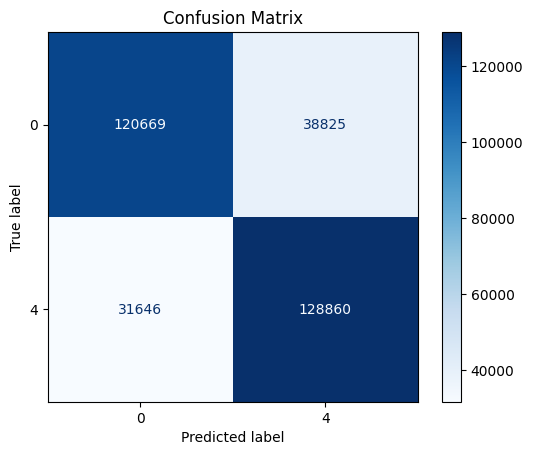

              precision    recall  f1-score   support

           0       0.79      0.76      0.77    159494
           4       0.77      0.80      0.79    160506

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



In [42]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Karışıklık Matrisi
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# Sınıflandırma Raporu
print(classification_report(y_test, y_pred))
